# Investigating Unfairness

In [1]:
import matplotlib.pyplot as plt
import duckdb as ddb
import numpy as np
from pathlib import Path
import pandas as pd
import seaborn as sns
from experiment_names import *

## Loading

In [2]:
ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = ROOT / "datasets/cloud_energy_consumption"

# LOOKING AT DEMAND-BASED PLACEMENTS (PBFD and CPU) 
RESULTS_DIR = ROOT / "demand_based_results/"
EXPERIMENTS = PBFD_PLACEMENTS | CPU_PLACEMENTS

# UNCOMMENT TO RUN CAPACITY-BASED PLACEMENTS (PBFD and CPU) 
# RESULTS_DIR = ROOT / "capacity_based_results/"
# EXPERIMENTS = CAP_PBFD_PLACEMENTS | CAP_CPU_PLACEMENTS

con = ddb.connect(database=':memory:')

In [3]:
def load_experiment(name, path):
    con.execute(f"""
        CREATE OR REPLACE VIEW {name} AS
        SELECT *
        FROM read_parquet('{RESULTS_DIR / path["path"]}')
    """)

In [4]:
# User data
con.query(f"""CREATE OR REPLACE TABLE vmhardware AS SELECT * FROM read_csv('{DATA_DIR}/vms/2024-12-14T000000Z_2025-04-13T235959Z/vms_fixed.csv')""")
vm_user = con.query("""SELECT vm_id, user_id from vmhardware""").df()

### Placements

In [5]:
#PLACEMENT_EXPERIMENTS = CAP_PBFD_PLACEMENTS | CAP_CPU_PLACEMENTS
PLACEMENT_EXPERIMENTS = PBFD_PLACEMENTS | CPU_PLACEMENTS

for view_name, cfg in PLACEMENT_EXPERIMENTS.items():
    load_experiment(view_name, cfg)

In [6]:
def show_count(experiment):

    print(f"Count unique for {experiment} simulation")

    con.query(f"""
        SELECT
            COUNT(DISTINCT vm_id) AS unique_vm_ids,
            COUNT(DISTINCT source_node) AS unique_source_nodes,
            COUNT(DISTINCT target_node) AS unique_target_nodes
        FROM {experiment}
    """).show()

## Migrations (source to target nodes)

In [7]:
for view_name, cfg in PLACEMENT_EXPERIMENTS.items():
    show_count(view_name)

Count unique for mm_pbfd_0_25_grid simulation
┌───────────────┬─────────────────────┬─────────────────────┐
│ unique_vm_ids │ unique_source_nodes │ unique_target_nodes │
│     int64     │        int64        │        int64        │
├───────────────┼─────────────────────┼─────────────────────┤
│           102 │                  49 │                  52 │
└───────────────┴─────────────────────┴─────────────────────┘

Count unique for mm_pbfd_0_30_grid simulation
┌───────────────┬─────────────────────┬─────────────────────┐
│ unique_vm_ids │ unique_source_nodes │ unique_target_nodes │
│     int64     │        int64        │        int64        │
├───────────────┼─────────────────────┼─────────────────────┤
│            82 │                  44 │                  51 │
└───────────────┴─────────────────────┴─────────────────────┘

Count unique for mm_pbfd_5_25_grid simulation
┌───────────────┬─────────────────────┬─────────────────────┐
│ unique_vm_ids │ unique_source_nodes │ unique_target_

In [8]:
def migrated_vm_and_user_counts(experiment, vm_user):
    migrated_vms = con.query(f"""
        SELECT DISTINCT vm_id
        FROM {experiment}
    """).df()

    impacted_users = migrated_vms.merge(vm_user, on="vm_id", how="left")

    return pd.Series({
        "unique_migrated_vms": migrated_vms["vm_id"].nunique(),
        "unique_impacted_users": impacted_users["user_id"].nunique(),
        "migrated_vms_without_user": impacted_users["user_id"].isna().sum(),
    })


impact_counts = pd.DataFrame([
    {
        "experiment": cfg["label"],
        **migrated_vm_and_user_counts(view_name, vm_user).to_dict(),
    }
    for view_name, cfg in PLACEMENT_EXPERIMENTS.items()
])

impact_counts

,experiment,unique_migrated_vms,unique_impacted_users,migrated_vms_without_user
0,MM/POWER (0-25),102,11,0
1,MM/POWER (0-30),82,4,0
2,MM/POWER (5-25),560,57,1
3,MM/POWER (5-30),565,57,1
4,MM/POWER (10-25),549,56,1
5,MM/POWER (10-30),552,56,1
6,MM/CPU (0-25),103,11,0
7,MM/CPU (0-30),84,4,0
8,MM/CPU (5-25),564,58,1
9,MM/CPU (5-30),566,58,1


## Which users get migrated most
Sorted by migrations and migrations_per_vm

In [9]:
def calc_migrations_per_user(experiment, vm_user):
    
    # select vms and migrations per vm for specific experiment
    vm_migrations = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()
    
    user_migrations = vm_migrations.merge(vm_user, on="vm_id", how="left")
    
    user_migrations = user_migrations.fillna(0)
    
    user_migrations = user_migrations.groupby("user_id")["migrations"].sum().reset_index()
    
    user_vm_count = vm_user.groupby("user_id")["vm_id"].count().reset_index(name="num_vms")

    user_migrations = user_migrations.merge(user_vm_count, on="user_id")

    user_migrations["migrations_per_vm"] = (
        user_migrations["migrations"] / user_migrations["num_vms"]
    )

    return user_migrations

In [10]:
def summarize_user_fairness(df):
    return {
        "mean": df["migrations_per_vm"].mean(),
        "median": df["migrations_per_vm"].median(),
        "gini": gini(df["migrations"].values),
        "top10_share": df.nlargest(10, "migrations")["migrations"].sum() / df["migrations"].sum(),
        "max_median_ratio": df["migrations"].max() / df["migrations"].median(),
    }

In [11]:
for view_name, cfg in PLACEMENT_EXPERIMENTS.items():
    tbl = calc_migrations_per_user(view_name, vm_user)
    print(f"\n{'='*60}")
    print(f"Experiment : {cfg['label']}")
    print(f"{'='*60}")
    print("\nSorted by total migrations (top 20):")
    print(tbl.sort_values("migrations", ascending=False).head(20).to_string(index=False))
    print("\nSorted by migrations_per_vm (top 20):")
    print(tbl.sort_values("migrations_per_vm", ascending=False).head(20).to_string(index=False))



Experiment : MM/POWER (0-25)

Sorted by total migrations (top 20):
 user_id  migrations  num_vms  migrations_per_vm
0fb4c56f      246594      102        2417.588235
7f7c4759       26623       72         369.763889
507c94d6       13873        8        1734.125000
f098d7fe        7258       43         168.790698
97f5bcf7        2827        6         471.166667
167938a6        1726       16         107.875000
756b77ce         112       20           5.600000
17de5058          30       27           1.111111
687850f0           7       30           0.233333
e4e85d1c           6        5           1.200000
41a5c328           1        4           0.250000

Sorted by migrations_per_vm (top 20):
 user_id  migrations  num_vms  migrations_per_vm
0fb4c56f      246594      102        2417.588235
507c94d6       13873        8        1734.125000
97f5bcf7        2827        6         471.166667
7f7c4759       26623       72         369.763889
f098d7fe        7258       43         168.790698
167938a6   

## Correlation Analysis
For each user computes: vm_count, total vCPUs, total memory, average CPU usage, and migrations
Output: correlation matrix distinguishing size-driven migration burdn from workload-driven burden

In [12]:
hw = con.query(f"""
    SELECT user_id,
    COUNT(vm_id) AS vm_count,
    SUM(vcpus) AS total_vcpus,
    SUM(memory_mb) AS total_memory_mb
    FROM vmhardware
    GROUP BY user_id
""").df()

In [13]:
def correlation_analysis(experiment, vm_user, hw):
    vm_mig = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()

    user_mig = (
        vm_mig.merge(vm_user, on="vm_id", how="left")
        .groupby("user_id")["migrations"]
        .sum()
        .reset_index()
    )

    feat = hw.merge(user_mig, on="user_id", how="left")
    feat["migrations"] = feat["migrations"].fillna(0)
    feat["migrations_per_vm"] = feat["migrations"] / feat["vm_count"]

    # Pearson correlation with migrations 
    #cols = ["vm_count", "total_vcpus", "total_memory_mb", "migrations", "migrations_per_vm"]

    #corr = feat[cols].corr()[["migrations_per_vm"]].drop("migrations_per_vm")
    #corr = feat[cols].corr()[["migrations"]].drop("migrations")
    #corr.columns = ["pearson_r"]

    print(f"\nCorrelation analysis for {experiment}:")
    #print(corr.sort_values("pearson_r", ascending=False).to_string())

    return feat


In [14]:
def corr_plot(feat, experiment):
    
    cols = ["vm_count", "total_vcpus", "total_memory_mb", "migrations", "migrations_per_vm"]
    corr = feat[cols].corr()

    plt.figure(figsize=(8,6))

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5
    )

    plt.title(f"Full Correlation Matrix: {experiment}")
    plt.tight_layout()
    plt.show()

In [15]:


def plot_both_correlations(feat, experiment):
    cols = ["vm_count", "total_vcpus", "total_memory_mb", "migrations", "migrations_per_vm"]

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    sns.heatmap(
        feat[cols].corr()[["migrations"]],
        annot=True,
        cmap="coolwarm",
        center=0,
        ax=axes[0]
    )
    axes[0].set_title("Correlation with total migrations")

    sns.heatmap(
        feat[cols].corr()[["migrations_per_vm"]],
        annot=True,
        cmap="coolwarm",
        center=0,
        ax=axes[1]
    )
    axes[1].set_title("Correlation with migrations per VM")

    plt.suptitle(f"Correlation Analysis: {experiment}")
    plt.tight_layout()
    plt.show()


Correlation analysis for mm_pbfd_0_25_grid:


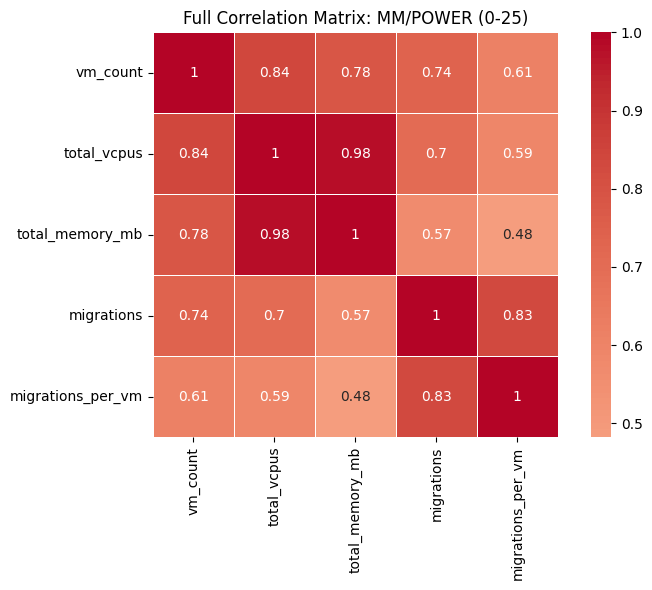


Correlation analysis for mm_pbfd_0_30_grid:


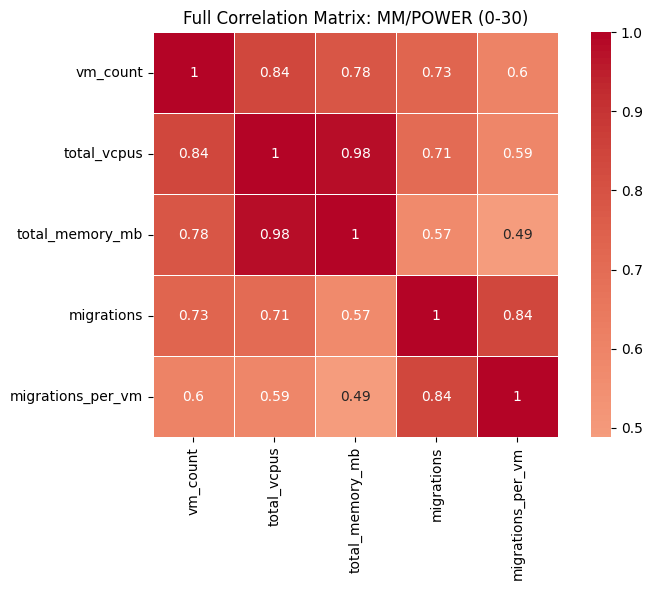


Correlation analysis for mm_pbfd_5_25_grid:


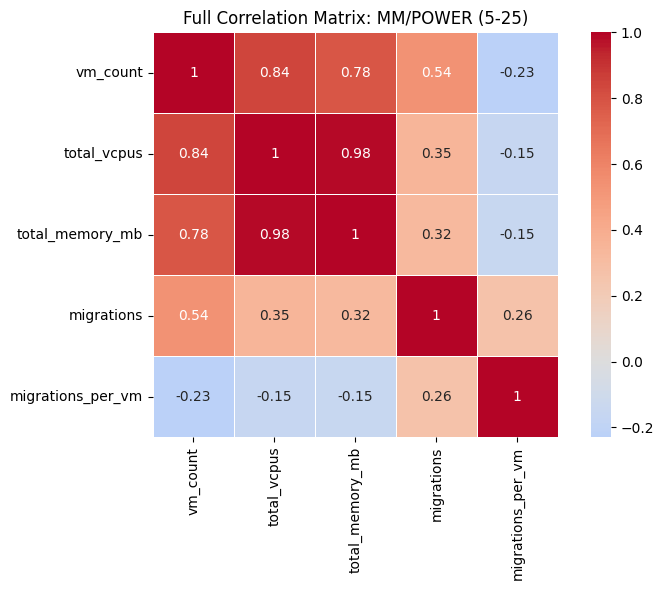


Correlation analysis for mm_pbdf_5_30_grid:


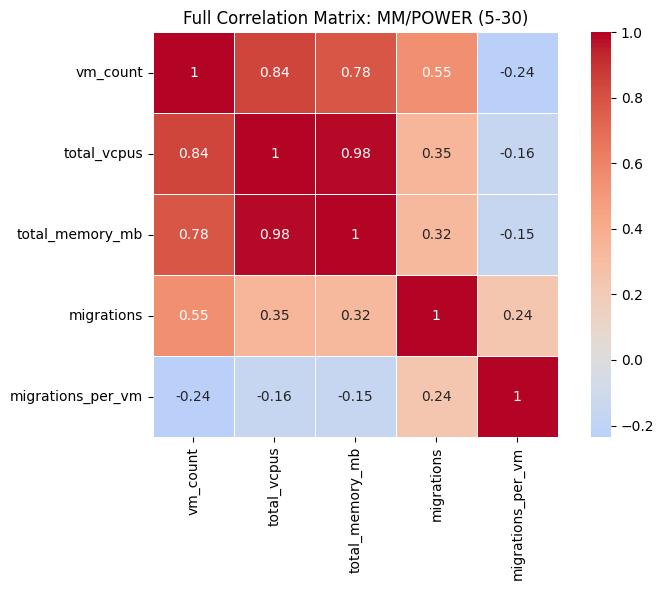


Correlation analysis for mm_pbfd_10_25_grid:


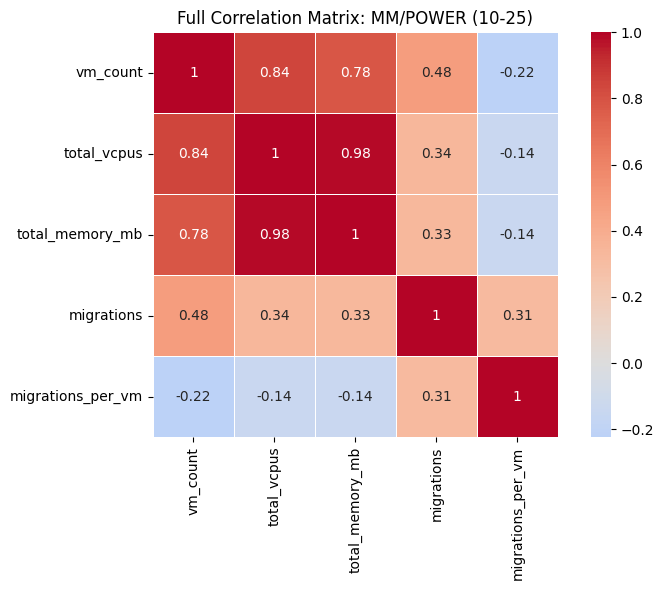


Correlation analysis for mm_pbdf_10_30_grid:


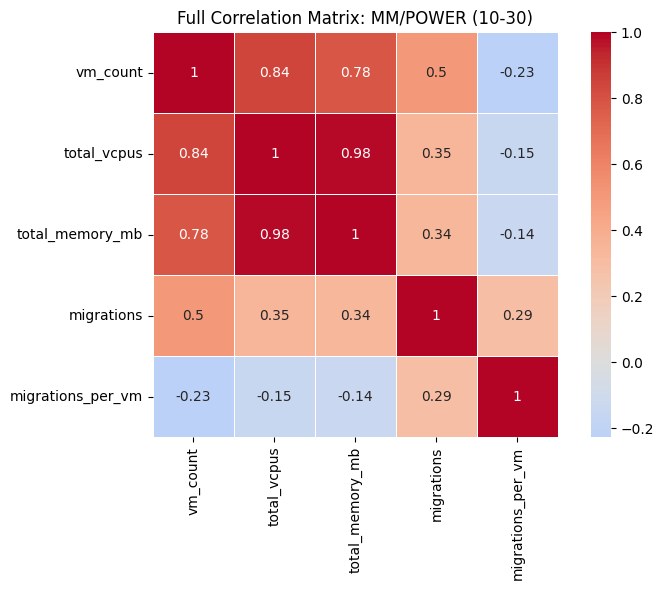


Correlation analysis for mm_cpu_bfd_0_25_grid:


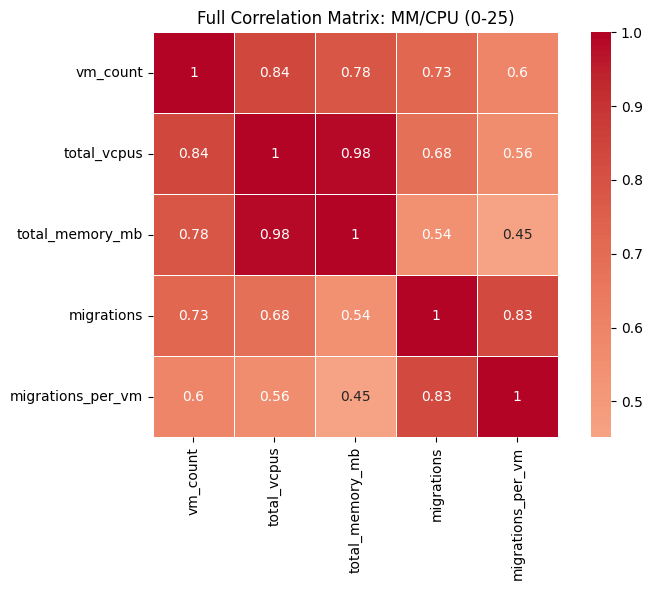


Correlation analysis for mm_cpu_bfd_0_30_grid:


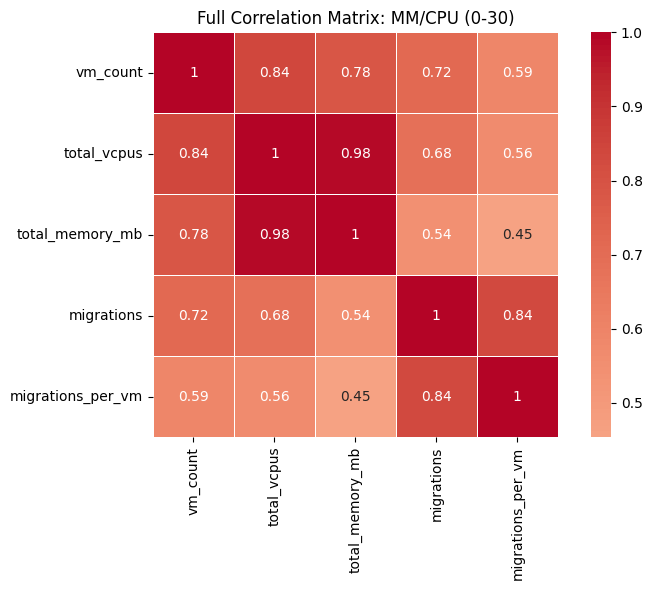


Correlation analysis for mm_cpu_bfd_5_25_grid:


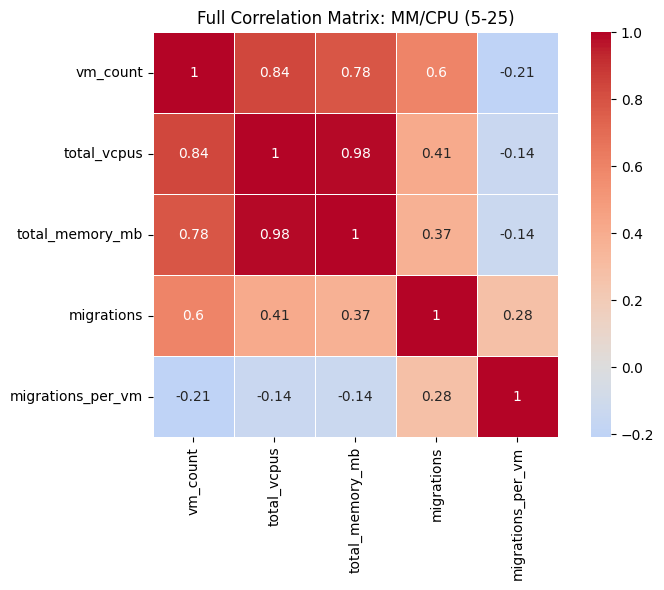


Correlation analysis for mm_cpu_bfd_5_30_grid:


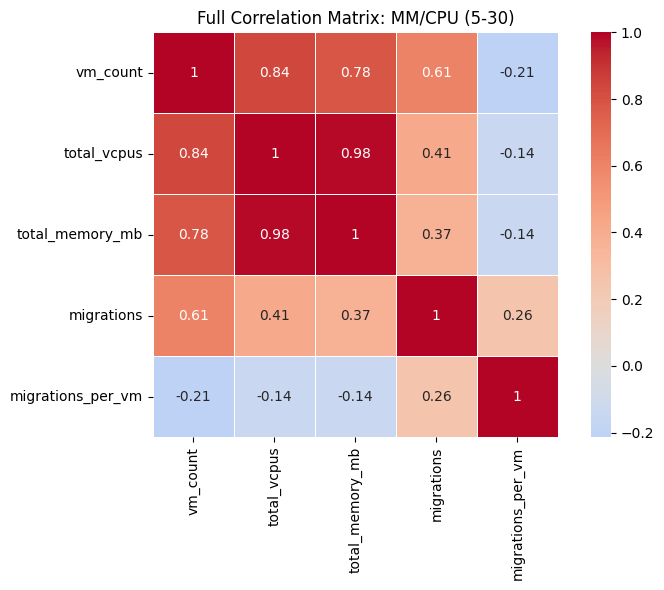


Correlation analysis for mm_cpu_bfd_10_25_grid:


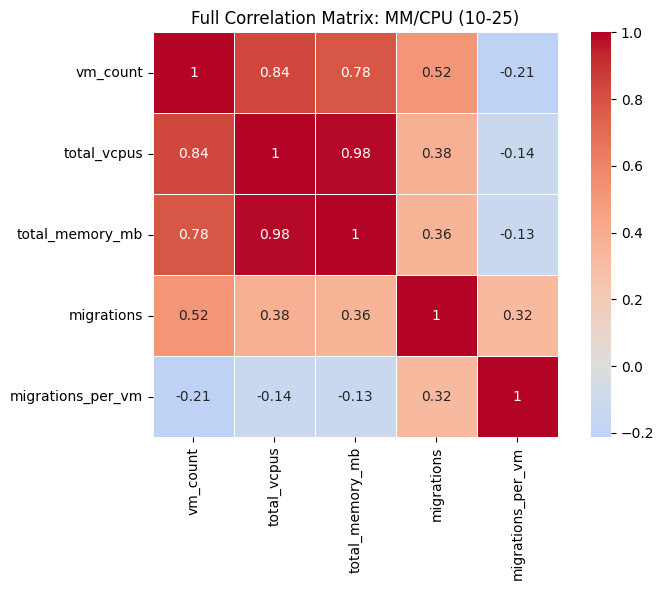


Correlation analysis for mm_cpu_bfd_10_30_grid:


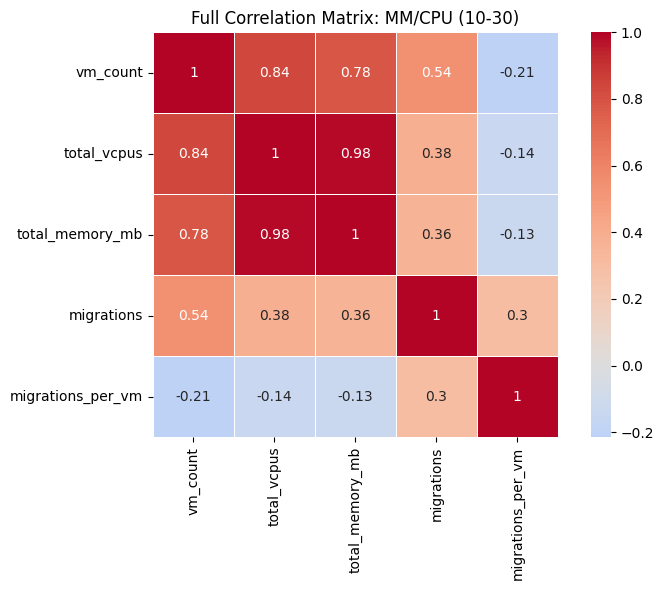

In [16]:
for view_name, cfg in PLACEMENT_EXPERIMENTS.items():
    feat = correlation_analysis(view_name, vm_user, hw)
    corr_plot(feat, cfg["label"])

## Lorenz Curve Contribution Analysis

This analysis measures concentration of migration burden among entities that were actually affected by migration. For users, the code first counts migrations per VM, maps each VM to its `user_id`, sums migrations per user, and normalizes by each user's VM count to get `migrations_per_vm`. It then keeps only users with at least one migration. The Lorenz curve sorts affected users from lowest to highest normalized burden and plots the cumulative share of burden. The Gini coefficient summarizes inequality in that curve: 0 means equal burden, while values closer to 1 mean the burden is concentrated among a small number of users.

The user top-share number is based on the top affected users by `migrations_per_vm`, not raw migration count. That is useful when you want to know whether users are disproportionately affected after accounting for how many VMs they own. The VM contribution analysis below uses raw VM migration counts, because each VM is one entity and does not need VM-count normalization.

In [17]:
def lorenz_contribution(experiment, vm_user, top_pct = 0.05):
    
    vm_mig = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()

    user_mig = (
        vm_mig.merge(vm_user, on="vm_id", how="left")
        .groupby("user_id")["migrations"]
        .sum()
        .reset_index()
    )

    user_mig = hw.merge(user_mig, on="user_id", how="left")
    user_mig["migrations"] = user_mig["migrations"].fillna(0)
    user_mig["migrations_per_vm"] = user_mig["migrations"] / user_mig["vm_count"]

    # Keep total users for context, but compute the Lorenz curve only over affected users.
    all_users = vm_user[["user_id"]].drop_duplicates()
    user_mig = all_users.merge(user_mig, on="user_id", how="left").fillna(0)
    affected_user_mig = user_mig[user_mig["migrations"] > 0].copy()

    affected_user_mig = affected_user_mig.sort_values("migrations_per_vm")
    vals = affected_user_mig["migrations_per_vm"].values
    n = len(vals)
    total = vals.sum()
    total_raw_migrations = affected_user_mig["migrations"].sum()

    lorenz_y = np.concatenate([[0], np.cumsum(vals) / total]) if total > 0 else np.array([0])
    lorenz_x = np.linspace(0, 1, n + 1)

    area = np.trapezoid(lorenz_y, lorenz_x) if total > 0 else 0
    gini = 1 - 2 * area if total > 0 else 0

    cutoff_idx = int(np.ceil(n * (1 - top_pct)))
    top_users = affected_user_mig.iloc[cutoff_idx:]
    top_share = vals[cutoff_idx:].sum() / total if total > 0 else 0.0
    top_raw_migration_share = top_users["migrations"].sum() / total_raw_migrations if total_raw_migrations > 0 else 0.0
    top_n_users = n - cutoff_idx

    result = {
        "experiment": experiment,
        "total_users": len(all_users),
        "affected_users": n,
        "gini": round(gini, 4),
        "top_pct_label": f"top {int(top_pct*100)}%",
        "top_n_users": top_n_users,
        "top_pct_normalized_burden_share": round(top_share, 4),
        "top_pct_raw_migration_share": round(top_raw_migration_share, 4),
        "lorenz_x"              : lorenz_x,
        "lorenz_y"              : lorenz_y,
    }

    print(f"\n[{experiment}]")
    print(f"  Total users    : {len(all_users)}")
    print(f"  Affected users : {n}")
    print(f"  User Gini      : {gini:.4f}")
    print(f"  Top {int(top_pct*100)}% affected users ({top_n_users} users) "
          f"account for {top_share*100:.1f}% of normalized migration burden")
    print(f"  The same users account for {top_raw_migration_share*100:.1f}% of all raw migrations")
    
    return result


def lorenz_vm_contribution(experiment, top_pct = 0.05):
    vm_mig = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()

    vals = vm_mig["migrations"].sort_values().values
    n = len(vals)
    total = vals.sum()

    lorenz_y = np.concatenate([[0], np.cumsum(vals) / total]) if total > 0 else np.array([0])
    lorenz_x = np.linspace(0, 1, n + 1)

    area = np.trapezoid(lorenz_y, lorenz_x) if total > 0 else 0
    gini = 1 - 2 * area if total > 0 else 0

    cutoff_idx = int(np.ceil(n * (1 - top_pct)))
    top_share = vals[cutoff_idx:].sum() / total if total > 0 else 0.0
    top_n_vms = n - cutoff_idx

    result = {
        "experiment": experiment,
        "affected_vms": n,
        "gini": round(gini, 4),
        "top_pct_label": f"top {int(top_pct*100)}%",
        "top_n_vms": top_n_vms,
        "top_pct_migration_share": round(top_share, 4),
        "lorenz_x": lorenz_x,
        "lorenz_y": lorenz_y,
    }

    print(f"\n[{experiment}] VM contribution")
    print(f"  Affected VMs   : {n}")
    print(f"  VM Gini        : {gini:.4f}")
    print(f"  Top {int(top_pct*100)}% affected VMs ({top_n_vms} VMs) "
          f"account for {top_share*100:.1f}% of all migrations")

    return result

In [18]:
user_lorenz_results = []
vm_lorenz_results = []

for exp_name, cfg in PLACEMENT_EXPERIMENTS.items():
    user_lorenz_results.append(lorenz_contribution(exp_name, vm_user, 0.1))
    vm_lorenz_results.append(lorenz_vm_contribution(exp_name, 0.1))




[mm_pbfd_0_25_grid]
  Total users    : 61
  Affected users : 11
  User Gini      : 0.7349
  Top 10% affected users (1 users) account for 45.8% of normalized migration burden
  The same users account for 82.5% of all raw migrations

[mm_pbfd_0_25_grid] VM contribution
  Affected VMs   : 102
  VM Gini        : 0.6845
  Top 10% affected VMs (10 VMs) account for 45.0% of all migrations

[mm_pbfd_0_30_grid]
  Total users    : 61
  Affected users : 4
  User Gini      : 0.4720
  Top 10% affected users (0 users) account for 0.0% of normalized migration burden
  The same users account for 0.0% of all raw migrations

[mm_pbfd_0_30_grid] VM contribution
  Affected VMs   : 82
  VM Gini        : 0.6486
  Top 10% affected VMs (8 VMs) account for 40.4% of all migrations

[mm_pbfd_5_25_grid]
  Total users    : 61
  Affected users : 57
  User Gini      : 0.5275
  Top 10% affected users (5 users) account for 28.1% of normalized migration burden
  The same users account for 4.8% of all raw migrations

[

## Top VM contribution shares

The cells below list the VM IDs in the absolute top 10, top 10%, and top 5% of VM-level migration burden. Since the migration data uses `vm_id` rather than a separate VM display name, `vm_id` is the VM name/identifier shown here.

In [19]:
def top_n_vm_contribution(experiment, vm_user, n=10):
    vm_mig = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()

    total_migrations = vm_mig["migrations"].sum()

    top_vms = (
        vm_mig.sort_values("migrations", ascending=False)
        .head(n)
        .merge(vm_user, on="vm_id", how="left")
    )
    top_vms["migration_share"] = top_vms["migrations"] / total_migrations

    print(f"\n[{experiment}] top {n} VMs")
    print(f"  Share of all migrations: {top_vms['migration_share'].sum() * 100:.1f}%")
    print(top_vms.to_string(index=False))

    return top_vms


def top_vm_contribution(experiment, vm_user, top_pct):
    vm_mig = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()

    total_migrations = vm_mig["migrations"].sum()
    top_n = max(1, int(np.ceil(len(vm_mig) * top_pct)))

    top_vms = (
        vm_mig.sort_values("migrations", ascending=False)
        .head(top_n)
        .merge(vm_user, on="vm_id", how="left")
    )
    top_vms["migration_share"] = top_vms["migrations"] / total_migrations

    print(f"\n[{experiment}] top {int(top_pct * 100)}% VMs")
    print(f"  VMs included: {top_n} of {len(vm_mig)}")
    print(f"  Share of all migrations: {top_vms['migration_share'].sum() * 100:.1f}%")
    print(top_vms.to_string(index=False))

    return top_vms


top_vm_tables = {}

for exp_name, cfg in PLACEMENT_EXPERIMENTS.items():
    top_vm_tables[(exp_name, "top_10_vms")] = top_n_vm_contribution(exp_name, vm_user, 10)
    top_vm_tables[(exp_name, "top_10_pct")] = top_vm_contribution(exp_name, vm_user, 0.10)
    top_vm_tables[(exp_name, "top_5_pct")] = top_vm_contribution(exp_name, vm_user, 0.05)


[mm_pbfd_0_25_grid] top 10 VMs
  Share of all migrations: 45.0%
   vm_id  migrations  user_id  migration_share
845db8a0       15816 0fb4c56f         0.052886
35ec4c58       15298 0fb4c56f         0.051154
1fe5084f       14963 0fb4c56f         0.050034
95c6a8d7       14037 0fb4c56f         0.046938
82db7e12       13105 0fb4c56f         0.043821
e9798179       12894 0fb4c56f         0.043116
3e322f7f       12580 0fb4c56f         0.042066
fafca9db       12538 0fb4c56f         0.041925
a24e9939       12040 0fb4c56f         0.040260
948abc0d       11222 0fb4c56f         0.037525

[mm_pbfd_0_25_grid] top 10% VMs
  VMs included: 11 of 102
  Share of all migrations: 48.4%
   vm_id  migrations  user_id  migration_share
845db8a0       15816 0fb4c56f         0.052886
35ec4c58       15298 0fb4c56f         0.051154
1fe5084f       14963 0fb4c56f         0.050034
95c6a8d7       14037 0fb4c56f         0.046938
82db7e12       13105 0fb4c56f         0.043821
e9798179       12894 0fb4c56f         0.0431

## User Group Analysis

Segments users into Small (1–5 VMs), Medium (6–20 VMs), and Large (>20 VMs). Compares average migrations per user, migrations per VM, and migration frequency across groups to reveal whether consolidation systematically disadvantages large tenants.


In [20]:
def group_size(num_vms):
        if num_vms <= 5:
            return "Small (1-5)"
        elif num_vms <= 20:
            return "Medium (6-20)"
        else:
            return "Large (>20)"

In [21]:
def user_group_analysis(experiment, vm_user):
    vm_mig = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()

    user_mig = (
        vm_mig.merge(vm_user, on="vm_id", how="left")
        .groupby("user_id")["migrations"]
        .sum()
        .reset_index()
    )

    user_vm_count = (
        vm_user.groupby("user_id")["vm_id"]
        .count()
        .reset_index(name="num_vms")
    )

    feat = user_vm_count.merge(user_mig, on="user_id", how="left").fillna(0)
    feat["migrations_per_vm"] = feat["migrations"] / feat["num_vms"]


    feat["group"] = feat["num_vms"].apply(group_size)


    group_order = ["Small (1-5)", "Medium (6-20)", "Large (>20)"]

    summary = ( 
        feat.groupby("group")
        .agg(
            n_users          = ("user_id",         "count"),
            avg_migrations   = ("migrations",      "mean"),
            avg_migrations_vm= ("migrations_per_vm","mean"),
            median_migrations= ("migrations", "median"),
            total_migrations = ("migrations", "sum"),
        )
        .reindex(group_order)
        .reset_index()
    )

    summary["avg_migrations"]    = summary["avg_migrations"].round(2)
    summary["avg_migrations_vm"] = summary["avg_migrations_vm"].round(3)
    summary["median_migrations"] = summary["median_migrations"].round(1)

    print(f"\n[{experiment}] — User Group Migration Summary")
    print(summary.to_string(index=False))

    
    return summary

In [22]:
def plot_user_groups_single(summary, experiment):

    # BAR PLOT
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    colors_map = {"Small (1-5)": "#4a90d9",
                "Medium (6-20)": "#f5a623",
                "Large (>20)": "#e63946"}
    
    bar_colors = [colors_map[g] for g in summary["group"]]
    
    for ax, col, ylabel in zip(
        axes,
        ["avg_migrations", "avg_migrations_vm", "median_migrations"],
        ["Avg migrations / user", "Avg migrations / VM", "Median migrations / user"]
    ):
        ax.bar(summary["group"], summary[col], color=bar_colors)
        ax.set_title(ylabel, fontsize=10)
        ax.set_xlabel("User size group")
        ax.tick_params(axis='x', rotation=15)
        
    fig.suptitle(f"User Group Analysis — {experiment}", fontsize=12)
    plt.tight_layout()
    #plt.savefig(f"user_group_analysis_{experiment}_GRID.png", dpi=150, bbox_inches="tight")
    plt.show()

In [23]:
def plot_user_groups_vm_migrations(all_summary):

    metric = "avg_migrations_vm"
    group_order = ["Small (1-5)", "Medium (6-20)", "Large (>20)"]
    experiment_order = ["MM/POWER (0-25)", "MM/POWER (0-30)", "MM/POWER (10-25)", "MM/POWER (10-30)", "MM/POWER (5-25)", "MM/POWER (5-30)"]

    pivot = (
        all_summary
        .pivot(index="group",
            columns="experiment",
            values=metric)
        .reindex(group_order)
    )
    pivot = pivot[experiment_order]

    fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(pivot.index)) #* 1.3  # space groups more
    width = 0.15  # increase bar width
    colors = plt.cm.Set3(np.linspace(0, 1, len(pivot.columns)))

    for i, exp in enumerate(pivot.columns):
        ax.bar(
            x + (i - len(pivot.columns)/2)*width + width/2,
            pivot[exp],
            width,
            label=exp,
            color=colors[i]
        )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    ax.set_ylabel("Average migrations per VM")
    ax.set_xlabel("User size group")
    ax.legend(title="Experiment")
    #plt.savefig("user_group_comparison_GRID.png", dpi=150, bbox_inches="tight")
    plt.tight_layout()
    plt.show()


[mm_pbfd_0_25_grid] — User Group Migration Summary
        group  n_users  avg_migrations  avg_migrations_vm  median_migrations  total_migrations
  Small (1-5)       36            0.19              0.040                0.0               7.0
Medium (6-20)       18         1029.89            128.820                0.0           18538.0
  Large (>20)        7        40073.14            422.498               30.0          280512.0

[mm_pbfd_0_30_grid] — User Group Migration Summary
        group  n_users  avg_migrations  avg_migrations_vm  median_migrations  total_migrations
  Small (1-5)       36            0.17              0.033                0.0               6.0
Medium (6-20)       18          695.83             86.979                0.0           12525.0
  Large (>20)        7        34454.29            351.886                0.0          241180.0

[mm_pbfd_5_25_grid] — User Group Migration Summary
        group  n_users  avg_migrations  avg_migrations_vm  median_migrations  total_

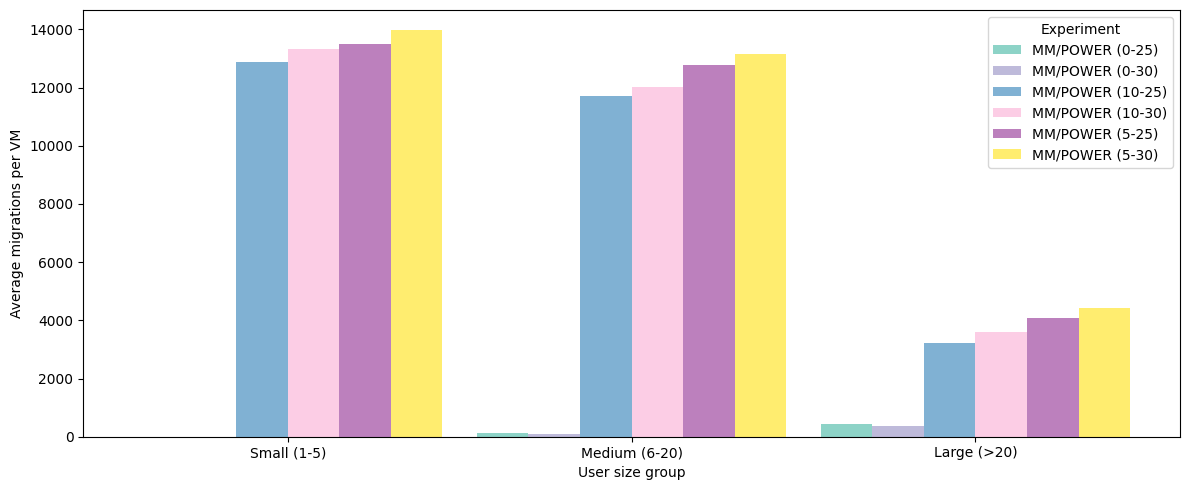

In [25]:
summaries = []

for view_name, cfg in EXPERIMENTS.items():
    if cfg["group"] != "MM":
        continue

    if cfg["type"] != "POWER":
        continue
    
    summary = (user_group_analysis(view_name, vm_user))
    summary["experiment"] = cfg["label"]
    summaries.append(summary)

all_summary = pd.concat(summaries, ignore_index=True)
plot_user_groups_vm_migrations(all_summary)


## Project-level fairness
Computes Gini coefficient and Jain's fairness index at the project level in addition to the existing user-level metrics. A result that is unfair by user but fair by project (or vice versa) significantly strengthens the thesis discussion.

In [26]:
def gini(x):
    x = np.array(x)
    if len(x) == 0:
        return 0
    if np.amin(x) < 0:
        x = x - np.amin(x)
    x = np.sort(x)
    cumx = np.cumsum(x)
    return (len(x) + 1 - 2 * np.sum(cumx) / cumx[-1]) / len(x)

def jains_fairness(x):
    x = np.array(x)
    if len(x) == 0:
        return 0
    return (np.sum(x) ** 2) / (len(x) * np.sum(x ** 2))

In [27]:
def project_fairness(experiment, vm_user):
    
    vm_mig = con.query(f"""
        SELECT vm_id, COUNT(*) AS migrations
        FROM {experiment}
        GROUP BY vm_id
    """).df()

    vm_project = con.query("""
        SELECT vm_id, project_id
        FROM vmhardware
    """).df()
    
    merged = vm_project.merge(vm_mig, on="vm_id", how="left").fillna(0)

    project_mig = merged.groupby("project_id")["migrations"].sum().reset_index(name="migrations")

    # computing fairness metrics (per migration count)
    vals = project_mig["migrations"].values

    gini_coeff = gini(vals)
    jains = jains_fairness(vals)

    print(f"\n[{experiment}] — Project-Level Fairness")
    print(f"  Projects : {len(project_mig)}")
    print(f"  Gini     : {gini_coeff:.4f}  (0 = equal, 1 = one project gets all)")
    print(f"  Jain     : {jains:.4f}  (1 = perfectly fair)")

    # per project normalised migrations (migrations / vms in project)
    proj_vm_count = (
        merged.groupby("project_id")["vm_id"]
        .count()
        .reset_index(name="vm_count")
    )

    project_mig = project_mig.merge(proj_vm_count, on="project_id")
    project_mig["migrations_per_vm"] = project_mig["migrations"] / project_mig["vm_count"]
    
    print("\nTop 10 projects by migrations:")
    print(
        project_mig.sort_values("migrations", ascending=False)
        .head(10)
        .to_string(index=False)
    )

    return project_mig

In [28]:
for exp_name, cfg in PLACEMENT_EXPERIMENTS.items():
    project_fairness(exp_name, vm_user)


[mm_pbfd_0_25_grid] — Project-Level Fairness
  Projects : 55
  Gini     : 0.9760  (0 = equal, 1 = one project gets all)
  Jain     : 0.0217  (1 = perfectly fair)

Top 10 projects by migrations:
project_id  migrations  vm_count  migrations_per_vm
  43d3e415    273223.0       162        1686.561728
  a5abeac5     13873.0         8        1734.125000
  c5e1c75e      7258.0        43         168.790698
  2a314fea      1733.0         2         866.500000
  f09054da      1344.0        27          49.777778
  17964622      1094.0         4         273.500000
  6a558d19       382.0         2         191.000000
  a9366595       112.0        19           5.894737
  7d4a4a5a        31.0        68           0.455882
  a99b2934         7.0        30           0.233333

[mm_pbfd_0_30_grid] — Project-Level Fairness
  Projects : 55
  Gini     : 0.9800  (0 = equal, 1 = one project gets all)
  Jain     : 0.0201  (1 = perfectly fair)

Top 10 projects by migrations:
project_id  migrations  vm_count  migr

Builds a side-by-side table of Gini/Jain by user AND by project for every experiment. Reveals discrepancies between the two levels.

In [29]:
def fairness_comparison_table(vm_user):
    rows = []

    for exp_name, cfg in PLACEMENT_EXPERIMENTS.items():
        # user-level
        vm_mig = con.query(f"""SELECT vm_id, COUNT(*) AS migrations FROM {exp_name} GROUP BY vm_id""").df()
        
        user_mig = (
            vm_mig.merge(vm_user, on="vm_id", how="left")
            .groupby("user_id")["migrations"]
            .sum()
            .reset_index()
        )

        all_users = vm_user[["user_id"]].drop_duplicates()
        user_vals = (
            all_users.merge(user_mig, on="user_id", how="left").fillna(0)["migrations"].values
        )

        # project-level
        vm_project = con.query("""SELECT vm_id, project_id FROM vmhardware""").df()

        project_vals = (
            vm_mig.merge(vm_project, on="vm_id", how="left")
            .groupby("project_id")["migrations"].sum().values
        )

        rows.append({
            "experiment": cfg["label"],
            "user_gini": round(gini(user_vals), 4),
            "user_jain": round(jains_fairness(user_vals), 4),
            "project_gini": round(gini(project_vals), 4),
            "project_jain": round(jains_fairness(project_vals), 4),
        })

    df = pd.DataFrame(rows)
    print("\nFairness Comparison Table (User vs Project):")
    print(df.to_string(index=False))
    return df

In [30]:
comparison = fairness_comparison_table(vm_user)


Fairness Comparison Table (User vs Project):
      experiment  user_gini  user_jain  project_gini  project_jain
 MM/POWER (0-25)     0.9730     0.0237        0.8680        0.1194
 MM/POWER (0-30)     0.9772     0.0221        0.4506        0.5518
 MM/POWER (5-25)     0.5902     0.4261        0.6137        0.3524
 MM/POWER (5-30)     0.5856     0.4301        0.6091        0.3538
MM/POWER (10-25)     0.6066     0.4105        0.6409        0.3334
MM/POWER (10-30)     0.6017     0.4155        0.6356        0.3334
   MM/CPU (0-25)     0.9736     0.0226        0.8671        0.1200
   MM/CPU (0-30)     0.9781     0.0208        0.4490        0.5535
   MM/CPU (5-25)     0.6055     0.4109        0.6260        0.3596
   MM/CPU (5-30)     0.6004     0.4150        0.6217        0.3600
  MM/CPU (10-25)     0.6150     0.4039        0.6493        0.3399
  MM/CPU (10-30)     0.6109     0.4080        0.6454        0.3392


In [31]:
print(PLACEMENT_EXPERIMENTS)

{'mm_pbfd_0_25_grid': {'path': 'MM_PBFD_0_25_grid/placements_MM_PBFD_0_25_grid.parquet', 'label': 'MM/POWER (0-25)', 'group': 'MM', 'type': 'POWER'}, 'mm_pbfd_0_30_grid': {'path': 'MM_PBFD_0_30_grid/placements_MM_PBFD_0_30_grid.parquet', 'label': 'MM/POWER (0-30)', 'group': 'MM', 'type': 'POWER'}, 'mm_pbfd_5_25_grid': {'path': 'MM_PBFD_5_25_grid/placements_MM_PBFD_5_25_grid.parquet', 'label': 'MM/POWER (5-25)', 'group': 'MM', 'type': 'POWER'}, 'mm_pbdf_5_30_grid': {'path': 'MM_PBFD_5_30_grid/placements_MM_PBFD_5_30_grid.parquet', 'label': 'MM/POWER (5-30)', 'group': 'MM', 'type': 'POWER'}, 'mm_pbfd_10_25_grid': {'path': 'MM_PBFD_10_25_grid/placements_MM_PBFD_10_25_grid.parquet', 'label': 'MM/POWER (10-25)', 'group': 'MM', 'type': 'POWER'}, 'mm_pbdf_10_30_grid': {'path': 'MM_PBFD_10_30_grid/placements_MM_PBFD_10_30_grid.parquet', 'label': 'MM/POWER (10-30)', 'group': 'MM', 'type': 'POWER'}, 'mm_cpu_bfd_0_25_grid': {'path': 'MM_CPU_BFD_0_25_grid/placements_MM_CPU_BFD_0_25_grid.parquet', 

In [32]:
def fairness_comparison_table(vm_user):
    rows = []

    # precompute VM counts per user
    user_vm_count = (
        vm_user.groupby("user_id")["vm_id"]
        .nunique()
        .reset_index(name="num_vms")
    )

    # project mapping
    vm_project = con.query("""SELECT vm_id, project_id FROM vmhardware""").df()

    project_vm_count = (
        vm_project.groupby("project_id")["vm_id"]
        .nunique()
        .reset_index(name="num_vms")
    )

    for exp_name, cfg in PLACEMENT_EXPERIMENTS.items():

        if cfg["group"] != "MM" or cfg["type"] != "POWER":
            continue

        vm_mig = con.query(f"""
            SELECT vm_id, COUNT(*) AS migrations
            FROM {exp_name}
            GROUP BY vm_id
        """).df()

        user_mig = (
            vm_mig.merge(vm_user, on="vm_id", how="left")
            .groupby("user_id")["migrations"]
            .sum()
            .reset_index()
        )

        user_feat = (
            user_vm_count.merge(user_mig, on="user_id", how="left")
            .fillna(0)
        )

        user_feat["mig_per_vm"] = (
            user_feat["migrations"] / user_feat["num_vms"]
        ).replace([np.inf, np.nan], 0)

        user_vals = user_feat["mig_per_vm"].values

        # normalised
        project_mig = (
            vm_mig.merge(vm_project, on="vm_id", how="left")
            .groupby("project_id")["migrations"]
            .sum()
            .reset_index()
        )

        project_feat = (
            project_vm_count.merge(project_mig, on="project_id", how="left")
            .fillna(0)
        )

        project_feat["mig_per_vm"] = (
            project_feat["migrations"] / project_feat["num_vms"]
        ).replace([np.inf, np.nan], 0)

        project_vals = project_feat["mig_per_vm"].values

        rows.append({
            "experiment": cfg["label"],
            "user_gini_norm": round(gini(user_vals), 4),
            "user_jain_norm": round(jains_fairness(user_vals), 4),
            "project_gini_norm": round(gini(project_vals), 4),
            "project_jain_norm": round(jains_fairness(project_vals), 4),
        })

    df = pd.DataFrame(rows)

    print("\nFairness Comparison Table (VM-normalised):")
    print(df.to_string(index=False))

    return df

In [33]:
comparison_df = fairness_comparison_table(vm_user)


Fairness Comparison Table (VM-normalised):
      experiment  user_gini_norm  user_jain_norm  project_gini_norm  project_jain_norm
 MM/POWER (0-25)          0.9522          0.0494             0.9366             0.0668
 MM/POWER (0-30)          0.9654          0.0375             0.9641             0.0363
 MM/POWER (5-25)          0.5585          0.4702             0.5595             0.4767
 MM/POWER (5-30)          0.5439          0.4877             0.5470             0.4899
MM/POWER (10-25)          0.6035          0.4276             0.5958             0.4439
MM/POWER (10-30)          0.5902          0.4429             0.5860             0.4543


## Plot

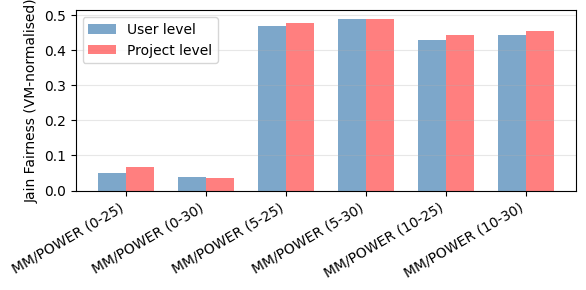

In [34]:
def plot_project_fairness(df):

    plt.figure(figsize=(6, 3))

    x = np.arange(len(df["experiment"]))
    width = 0.35

    plt.bar(
        x - width/2,
        df["user_jain_norm"],
        width,
        label="User level",
        color="steelblue",
        alpha=0.7
    )

    plt.bar(
        x + width/2,
        df["project_jain_norm"],
        width,
        label="Project level",
        color="red",
        alpha=0.5
    )

    #plt.ylim(0, 0.4)

    plt.xticks(x, df["experiment"], rotation=30, ha="right")

    plt.ylabel("Jain Fairness (VM-normalised)")
    #plt.title("User vs Project-Level Fairness Across Experiments")

    plt.grid(axis="y", alpha=0.3)
    plt.legend()

    plt.tight_layout()
    #plt.savefig("user_project_fairness_comparison_GRID.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_project_fairness(comparison_df)

## Total number of migrations

In [35]:
def total_migrations_per_experiment(experiment):
    return con.query(f"""
        SELECT COUNT(*) AS total_migrations
        FROM {experiment}
    """).df()["total_migrations"].iloc[0]


total_migrations = pd.DataFrame([
    {
        "experiment": cfg["label"],
        "total_migrations": total_migrations_per_experiment(view_name),
    }
    for view_name, cfg in PLACEMENT_EXPERIMENTS.items()
])

total_migrations

,experiment,total_migrations
0,MM/POWER (0-25),299057
1,MM/POWER (0-30),253711
2,MM/POWER (5-25),4331585
3,MM/POWER (5-30),4510123
4,MM/POWER (10-25),3871675
5,MM/POWER (10-30),4059686
6,MM/CPU (0-25),291063
7,MM/CPU (0-30),245818
8,MM/CPU (5-25),4201319
9,MM/CPU (5-30),4360319
